<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Statistics-for-Data-Scientists/blob/main/01_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis**

This notebook covers Exploratory Data Analysis:
1. Elements of Structured Data & Rectangular Data
2. Estimates of Location
3. Estimates of Variability
4. Exploring the Data Distribution
5. Exploring Binary and Categorical Data
6. Correlation
7. Exploring Two or More Variables
8. Summary

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the standard dataset used in Chapter 1 directly from the authors' repository
STATE_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/state.csv'
state = pd.read_csv(STATE_CSV)

print(state.head())

        State  Population  Murder.Rate Abbreviation
0     Alabama     4779736          5.7           AL
1      Alaska      710231          5.6           AK
2     Arizona     6392017          4.7           AZ
3    Arkansas     2915918          5.6           AR
4  California    37253956          4.4           CA


## **1. Elements of Structured Data & Rectangular Data**

Data fundamentally arrives in an unstructured format—from raw text and audio signals to irregular log files. The primary task of a data scientist is to transform this raw information into structured, rectangular data. This rectangular matrix structure, commonly referred to as a data frame in R or Python (via the pandas library), forms the bedrock of modern statistical modeling. In this architecture, each row represents a distinct record (or observation), and each column represents a feature (or variable).

Understanding the specific typology of these features is paramount. Features are generally classified into two broad branches: numeric and categorical. Numeric data can be continuous (taking any value within a range, such as wind speed) or discrete (taking integer values, such as the number of events). Categorical data, on the other hand, represents discrete categories and can be nominal (unordered) or ordinal (ordered). Recognizing these data types is not merely a semantic exercise; it dictates the visual tools, statistical tests, and machine learning algorithms that can be legitimately applied to the dataset.

## **2. Estimates of Location**

When first confronted with a vast array of numbers, the human mind struggles to synthesize the information. Therefore, the most fundamental step in data exploration is identifying a 'typical' value for each feature. This is known academically as an estimate of location, or central tendency. While the arithmetic mean is the most ubiquitous metric—calculated by summing all values and dividing by the number of observations—it suffers from a critical vulnerability: extreme sensitivity to outliers.

To counter this fragility, statisticians have developed robust alternatives. The trimmed mean, for instance, calculates the average after deliberately discarding a fixed percentage of the extreme values at both tails of the distribution, thereby neutralizing the disproportionate impact of anomalies. Similarly, the median represents the strict middle value of a sorted dataset, ensuring that a single massive outlier cannot distort our understanding of the data's true center. The selection between mean, trimmed mean, and median is dependent on the distribution's skewness and the domain-specific impact of extreme values.

In [2]:
# Calculating the mean population
mean_pop = state['Population'].mean()

# Calculating the trimmed mean (dropping the top and bottom 10%)
trimmed_mean_pop = trim_mean(state['Population'], 0.1)

# Calculating the median population
median_pop = state['Population'].median()

print(f"Mean:         {mean_pop:,.0f}")
print(f"Trimmed Mean: {trimmed_mean_pop:,.0f}")
print(f"Median:       {median_pop:,.0f}")

Mean:         6,162,876
Trimmed Mean: 4,783,697
Median:       4,436,370


## **3. Estimates of Variability**

Location alone paints an incomplete picture. Two datasets can share the exact same mean but possess entirely different distributions. Therefore, we must measure variability, also known as dispersion. This dimension tells us how tightly clustered or widely dispersed the data points are around the central value. The variance and its square root, the standard deviation, are the classical measures, functioning by squaring the deviations from the mean.

However, just as the mean is sensitive to outliers, so too is the standard deviation—even more so, because the squaring operation exponentially magnifies the effect of distant anomalies. For robust analysis, we turn to order-based statistics. The Mean Absolute Deviation (MAD) evaluates the average absolute distance from the mean, avoiding the squaring distortion. Furthermore, the Interquartile Range (IQR)—the difference between the 75th and 25th percentiles—provides a highly resilient measure of spread that focuses strictly on the middle 50% of the dataset, effectively ignoring extreme tails.

In [3]:
# Calculating standard deviation
std_dev = state['Population'].std()

# Calculating Interquartile Range (IQR)
iqr = state['Population'].quantile(0.75) - state['Population'].quantile(0.25)

# Calculating robust Mean Absolute Deviation (using Pandas absolute deviation from the median)
mad = state['Population'].mad() if hasattr(state['Population'], 'mad') else (state['Population'] - state['Population'].median()).abs().median()

print(f"Standard Deviation: {std_dev:,.0f}")
print(f"IQR:                {iqr:,.0f}")
print(f"Median Abs Dev:     {mad:,.0f}")

Standard Deviation: 6,848,235
IQR:                4,847,308
Median Abs Dev:     2,596,702


## **4. Exploring the Data Distribution**

Moving beyond single-number statistical summaries, visual exploration of the data distribution allows the analyst to perceive the shape, skewness, and multi-modality of the variable. Percentiles are foundational here, indicating the value below which a given percentage of observations fall. These percentiles are brilliantly visualized through boxplots, originally pioneered by John Tukey. A boxplot succinctly displays the median, the IQR, and potential outliers in a single geometrical figure.

For a more granular view, histograms and density plots are employed. A histogram bins the continuous data into discrete intervals and plots the frequency of observations within each bin, revealing the macroscopic architecture of the data. Density plots provide a smoother, continuous estimate of the distribution, often utilizing kernel density estimation (KDE). These visual tools are indispensable; they expose underlying structures—such as bi-modal distributions—that summary statistics like the mean and variance completely obscure.

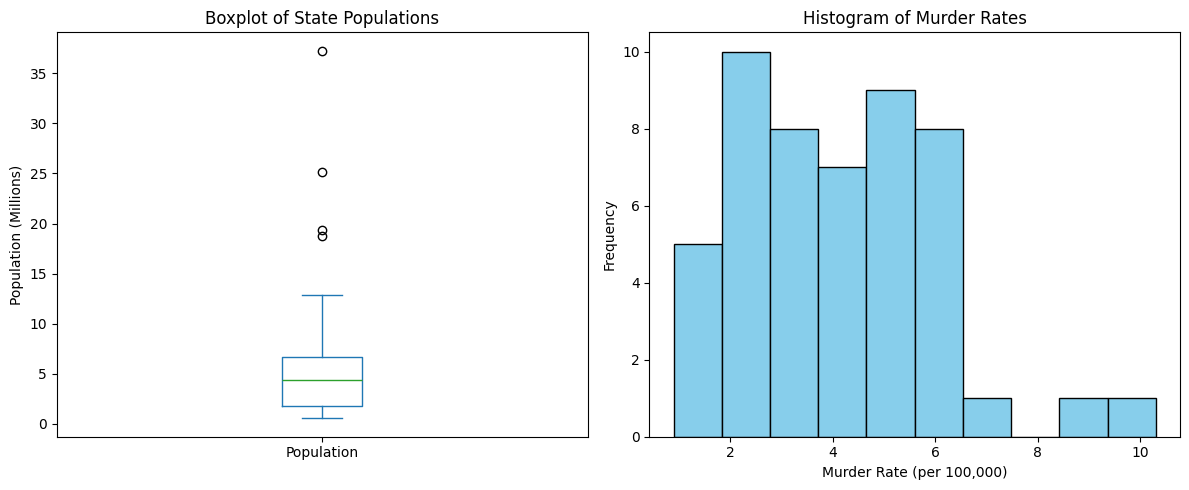

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plotting a Boxplot for Population (in millions for readability)
(state['Population'] / 1_000_000).plot.box(ax=ax1)
ax1.set_ylabel('Population (Millions)')
ax1.set_title('Boxplot of State Populations')

# Plotting a Histogram for Murder Rate
ax2.hist(state['Murder.Rate'], bins=10, color='skyblue', edgecolor='black')
ax2.set_xlabel('Murder Rate (per 100,000)')
ax2.set_ylabel('Frequency')
ax2.set_title('Histogram of Murder Rates')

plt.tight_layout()
plt.show()

## **5. Exploring Binary and Categorical Data**

When dealing with categorical or binary data, the analytical paradigm shifts. Continuous metrics like mean and variance lose their direct interpretation. Instead, we rely on proportions, frequencies, and the mode. The mode simply represents the most frequently occurring category within the dataset.

To conceptualize this graphically, bar charts are the standard convention, displaying the frequency or proportion of each distinct category. It is crucial to distinguish a bar chart from a histogram: a bar chart represents discrete, separate categories (often reordered for aesthetic clarity), whereas a histogram represents a continuous, ordered scale on the x-axis. Additionally, when dealing with probabilities and financial modeling, the concept of 'expected value' becomes critical. It calculates the mean outcome by weighting each potential categorical outcome by its assigned probability.

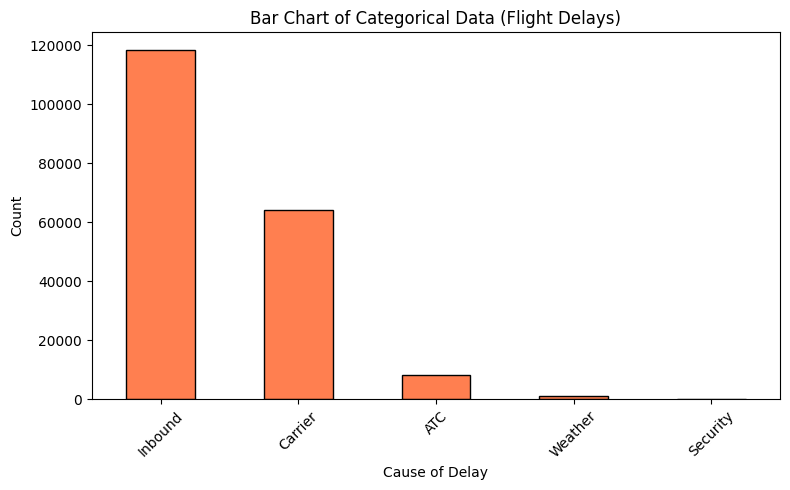

In [5]:
# Simulating categorical data based on the book's context (e.g., region delays)
# Using dummy frequency data for the concept of Bar Charts
dfw_data = pd.Series({
    'Carrier': 64263,
    'ATC': 8404,
    'Weather': 1123,
    'Security': 233,
    'Inbound': 118427
})

ax = dfw_data.sort_values(ascending=False).plot.bar(figsize=(8, 5), color='coral', edgecolor='black')
ax.set_xlabel('Cause of Delay')
ax.set_ylabel('Count')
ax.set_title('Bar Chart of Categorical Data (Flight Delays)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **6. Correlation**

Data science rarely examines variables in absolute isolation; the immense value lies in discovering the relationships between them. Correlation explores how two continuous variables move in tandem. The Pearson correlation coefficient is the standard metric, mathematically bounding the relationship between -1 (perfect inverse correlation) and +1 (perfect positive correlation), with 0 indicating an absence of linear association.

It is fundamentally imperative to remember the academic mantra: correlation does not imply causation. A high correlation merely signifies a statistical association, which could be driven by a confounding third variable rather than a direct mechanical link. To systematically explore multiple variables simultaneously, data scientists utilize correlation matrices and visual heatmaps. These tools provide an immediate, color-coded macroscopic overview of the multivariate relationships within a complex dataset, efficiently highlighting collinear features that might negatively impact regression models.

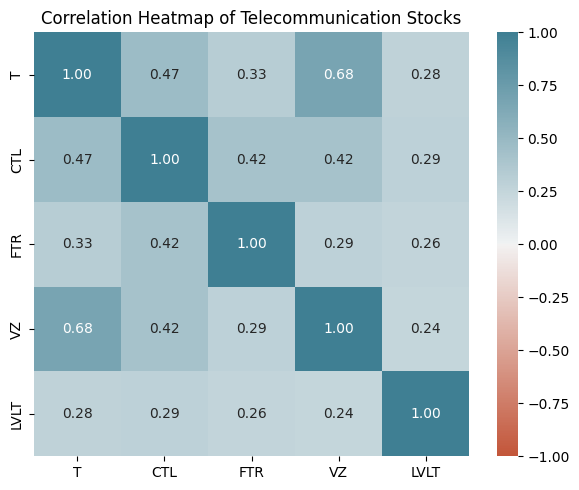

In [6]:
# Loading the ETF dataset from the authors' repo for correlation example
SP500_SECTORS_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_sectors.csv'
sp500_sym = pd.read_csv(SP500_SECTORS_CSV)
SP500_DATA_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz'
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)

# Filtering for a subset of tech stocks for clarity
telecom_symbols = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecom_symbols]

plt.figure(figsize=(6, 5))
ax = sns.heatmap(telecom.corr(), vmin=-1, vmax=1,
                 cmap=sns.diverging_palette(20, 220, as_cmap=True),
                 annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Telecommunication Stocks')
plt.tight_layout()
plt.show()

## **7. Exploring Two or More Variables**

While standard scatterplots are excellent for visualizing the relationship between two variables when the dataset is relatively small, they severely degrade in utility when confronted with large datasets due to 'overplotting'—where thousands of data points overlap into indistinguishable ink blobs.

To rigorously analyze bivariate relationships in massive datasets, we transition to density-based visualizations. Hexagonal binning solves the overplotting dilemma by dividing the geometric space into hex-shaped bins and coloring them based on the density of observations falling within them. Similarly, contour plots provide a topographical map of density, drawing isolines that connect regions of equal data concentration. These advanced exploratory techniques allow the analyst to discern the core mass of the data relationship, effectively filtering out the visual noise generated by peripheral outliers.

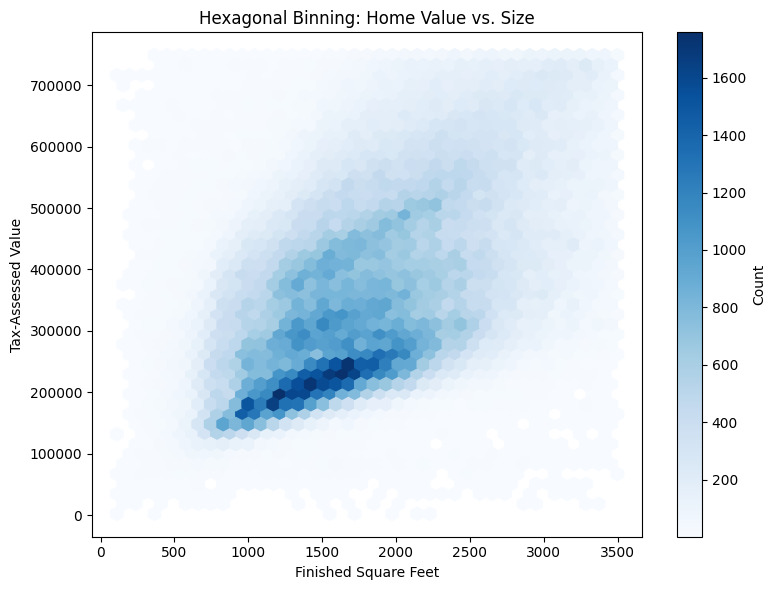

In [7]:
# Loading King County Tax dataset from the authors' repo for Hexbin example
KC_TAX_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/kc_tax.csv.gz'
kc_tax = pd.read_csv(KC_TAX_CSV)

# Filtering for standard housing ranges to remove extreme skewness
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]

fig, ax = plt.subplots(figsize=(8, 6))
# Hexagonal Binning
hb = ax.hexbin(kc_tax0.SqFtTotLiving, kc_tax0.TaxAssessedValue,
               gridsize=40, cmap='Blues', mincnt=1)
ax.set_xlabel('Finished Square Feet')
ax.set_ylabel('Tax-Assessed Value')
ax.set_title('Hexagonal Binning: Home Value vs. Size')
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Count')

plt.tight_layout()
plt.show()

## **8. Summary**

Exploratory data analysis (EDA), pioneered by John Tukey, set a foundation for the field of data science. The key idea of EDA is that the first and most important step in any project based on data is to look at the data. By summarizing and visualizing the data, you can gain valuable intuition and understanding of the project.

This chapter has reviewed concepts ranging from simple metrics, such as estimates of location and variability, to rich visual displays that explore the relationships between multiple variables, as in Figure 1-12. The diverse set of tools and techniques being developed by the open source community, combined with the expressiveness of the R and Python languages, has created a plethora of ways to explore and analyze data. Exploratory analysis should be a cornerstone of any data science project.